# Projet - Modèle 1

$$\mathrm{d}V_t = V_t\left(\tfrac23 - \tfrac43 P_t + X_t\right)\mathrm{d}t, \qquad \mathrm{d}P_t = P_t(-1 + V_t)\,\mathrm{d}t$$

**Q1.1** proposer et valider un modèle pour $(X_t)$. **Q1.2** étudier la probabilité d'extinction.

In [29]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt

## 1. Données

In [30]:
# colonne 0 = victimes V, colonne 1 = predateurs P
data = np.loadtxt('virus4.csv', delimiter=',')
V = data[:, 0]
P = data[:, 1]
N = len(data)
N, V[0], P[0]

(2000, np.float64(1.0), np.float64(0.4))

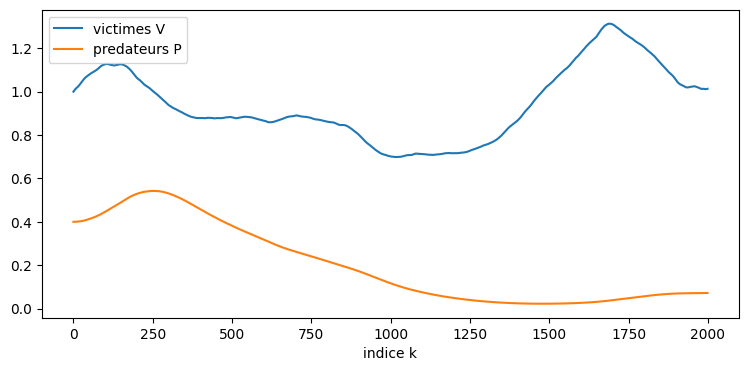

In [31]:
plt.figure(figsize=(9, 4))
plt.plot(V, label='victimes V')
plt.plot(P, label='predateurs P')
plt.xlabel('indice k')
plt.legend()
plt.show()

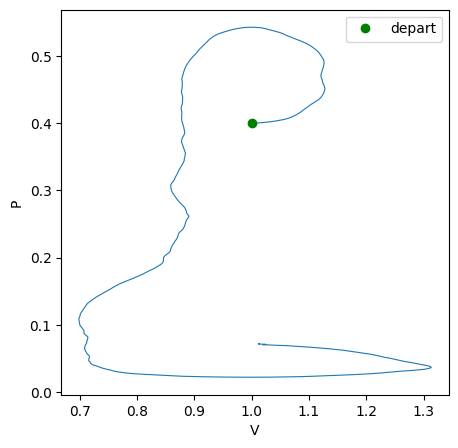

In [32]:
# portrait de phase
plt.figure(figsize=(5, 5))
plt.plot(V, P, linewidth=0.8)
plt.plot(V[0], P[0], 'go', label='depart')
plt.xlabel('V')
plt.ylabel('P')
plt.legend()
plt.show()

## 2. Modèle déterministe

Paramètres $a = \tfrac23$, $b = \tfrac43$, $c = 1$, $d = 1$, équilibre $(1, \tfrac12)$.
$X_t$ perturbe le taux de croissance des victimes.

## 3. Pas de temps

L'équation des prédateurs n'a pas de bruit, donc $\Delta t = \dfrac{P_{k+1} - P_k}{P_k(V_k - 1)}$.

In [33]:
# on calcule dt sur les points ou V n'est pas proche de 1 (denominateur nul), puis on prend la valeur typique
num = P[1:] - P[:-1]
den = P[:-1] * (V[:-1] - 1)
ok = np.abs(den) > 1e-3
dt = round(np.median(num[ok] / den[ok]), 3)
tau = N * dt
dt, tau

(np.float64(0.015), np.float64(30.0))

## 4. Extraction de $X_t$

$$X_k = \frac{V_{k+1} - V_k}{V_k\,\Delta t} - \tfrac23 + \tfrac43 P_k$$

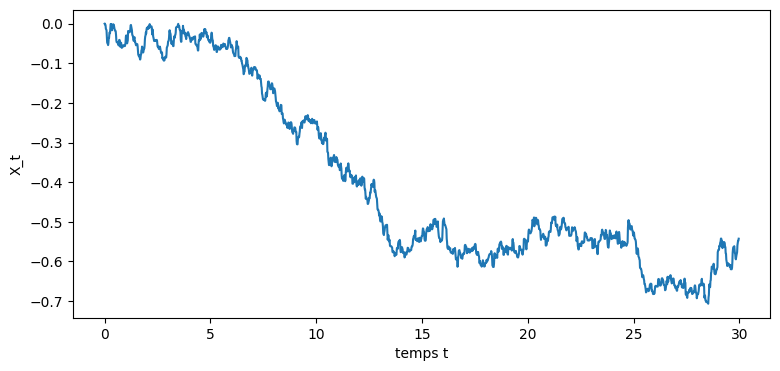

In [34]:
X = (V[1:] - V[:-1]) / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
t = np.arange(len(X)) * dt

plt.figure(figsize=(9, 4))
plt.plot(t, X)
plt.xlabel('temps t')
plt.ylabel('X_t')
plt.show()

In [35]:
# verification : reinjecter X dans Euler doit redonner V exactement
Vrec = np.zeros(N)
Vrec[0] = V[0]
for k in range(N - 1):
    Vrec[k+1] = Vrec[k] + Vrec[k] * (2/3 - 4/3 * P[k] + X[k]) * dt
np.max(np.abs(Vrec - V))

np.float64(0.0)

## 5. Modèle d'Ornstein-Uhlenbeck

$X_t$ est régulier et revient vers une valeur négative, ce qui fait penser au processus d'Ornstein-Uhlenbeck
$$\mathrm{d}X_t = -\gamma\,(X_t - m)\,\mathrm{d}t + s\,\mathrm{d}B_t$$

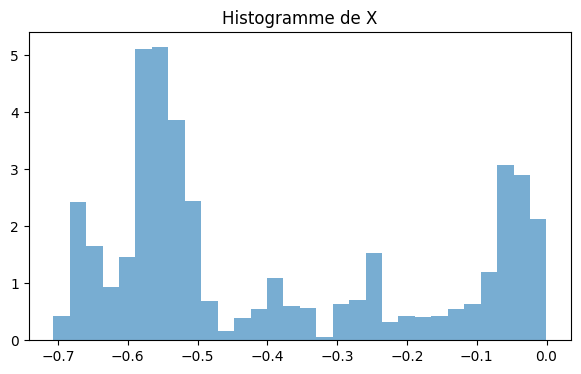

In [36]:
# histogramme de X
plt.figure(figsize=(7, 4))
plt.hist(X, bins=30, density=True, alpha=0.6)
plt.title('Histogramme de X')
plt.show()

## 6. Estimation des paramètres

Le schéma d'Euler de l'OU est un AR(1) : $X_{k+1} = m + \rho(X_k - m) + \varepsilon_k$ avec $\rho = e^{-\gamma\,\Delta t}$.

In [37]:
x0 = X[:-1]
x1 = X[1:]
rho = np.cov(x0, x1, ddof=1)[0, 1] / np.var(x0, ddof=1)
m = (np.mean(x1) - rho * np.mean(x0)) / (1 - rho)
eps = x1 - (m + rho * (x0 - m))     # residus
gamma = -np.log(rho) / dt
s = np.std(eps, ddof=1) / np.sqrt((1 - rho**2) / (2 * gamma))
gamma, m, s

(np.float64(0.069276521888007),
 np.float64(-0.6565149939412765),
 np.float64(0.052104393128062365))

In [38]:
# qualite du modele : pour un OU les residus sont gaussiens et sans memoire
p_norm = scs.ks_1samp(eps, scs.norm(0, np.std(eps, ddof=1)).cdf).pvalue
autocorr = np.corrcoef(eps[:-1], eps[1:])[0, 1]
p_norm, autocorr

(np.float64(2.732409397794702e-14), np.float64(0.25729177556246746))

Les résidus ne sont pas tout à fait gaussiens et gardent un peu de mémoire. Le vrai $X_t$ est donc un peu
plus régulier qu'un OU pur. On garde l'OU, qui capture le retour vers la moyenne, en signalant cette limite.

Pour quantifier la validation, on teste si des statistiques de $X$ (amplitude et autocorrélation) tombent
dans la masse de ce que produit le modèle OU. C'est un test de Monte-Carlo, dans l'esprit des tests
d'adéquation des TP. Si la statistique réelle est dans la plage du modèle, la $p$-valeur est grande et on ne
rejette pas.

In [39]:
def ou_path(rng):
    # une trajectoire d'Ornstein-Uhlenbeck avec les parametres ajustes
    o = np.zeros(len(X))
    o[0] = X[0]
    sig = np.std(eps, ddof=1)
    for k in range(1, len(X)):
        o[k] = m + rho * (o[k-1] - m) + sig * rng.standard_normal()
    return o

def amplitude(x):
    return np.max(np.abs(x))

def autocorr50(x):
    return np.corrcoef(x[:-50], x[50:])[0, 1]

# distribution des statistiques sous le modele OU
rng = np.random.default_rng(0)
amp_sim = []
ac_sim = []
for _ in range(500):
    o = ou_path(rng)
    amp_sim.append(amplitude(o))
    ac_sim.append(autocorr50(o))
amp_sim = np.array(amp_sim)
ac_sim = np.array(ac_sim)

for nom, reel, sim in [('amplitude', amplitude(X), amp_sim), ('autocorr lag50', autocorr50(X), ac_sim)]:
    p = 2 * min(np.mean(sim >= reel), np.mean(sim <= reel))
    bas, haut = np.percentile(sim, 5), np.percentile(sim, 95)
    print('%-14s reel = %.3f   modele [5%%, 95%%] = [%.3f, %.3f]   p = %.3f' % (nom, reel, bas, haut, p))

amplitude      reel = 0.707   modele [5%, 95%] = [0.449, 0.868]   p = 0.740
autocorr lag50 reel = 0.980   modele [5%, 95%] = [0.903, 0.985]   p = 0.380


## 7. Validation par simulation du système complet

Plutôt que de tester la série bruitée, on simule le système couplé entier avec notre OU et on compare aux données.

In [41]:
def simule(rng, n):
    # simule (V, P) sur n pas, X etant un Ornstein-Uhlenbeck
    Vs = np.zeros(n); Ps = np.zeros(n); Xs = np.zeros(n)
    Vs[0], Ps[0], Xs[0] = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(n - 1):
        Xs[k+1] = m + r * (Xs[k] - m) + e * rng.standard_normal()
        Vs[k+1] = Vs[k] + Vs[k] * (2/3 - 4/3 * Ps[k] + Xs[k]) * dt
        Ps[k+1] = Ps[k] + Ps[k] * (-1 + Vs[k]) * dt
    return Vs, Ps

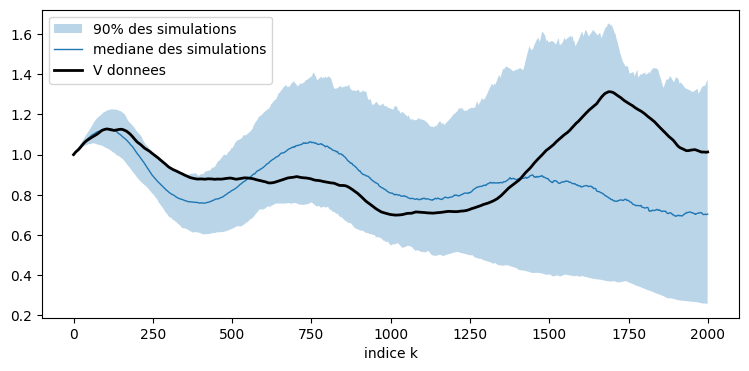

In [42]:
rng = np.random.default_rng(0)
K = 300
sims = np.zeros((K, N))
for i in range(K):
    Vs, Ps = simule(rng, N)
    sims[i] = Vs

# on trace la bande ou passent 90% des simulations, plus la mediane et les donnees
bas = np.percentile(sims, 5, axis=0)
haut = np.percentile(sims, 95, axis=0)
med = np.percentile(sims, 50, axis=0)

plt.figure(figsize=(9, 4))
plt.fill_between(range(N), bas, haut, alpha=0.3, label='90% des simulations')
plt.plot(med, color='tab:blue', linewidth=1, label='mediane des simulations')
plt.plot(V, 'k', linewidth=2, label='V donnees')
plt.xlabel('indice k')
plt.legend()
plt.show()

Les trajectoires simulées ont la même allure et la même amplitude que les données. Le modèle reproduit donc
le bon comportement, ce qui valide qualitativement le choix de l'Ornstein-Uhlenbeck.

## 8. Probabilité d'extinction (Q1.2)

Une population est éteinte au premier instant où $V_t \le 0.01$ ou $P_t \le 0.01$. On simule beaucoup de
trajectoires et on regarde l'extinction des victimes et des prédateurs.

In [43]:
seuil = 0.01
M = 2000
rng = np.random.default_rng(0)
nb_V = 0; nb_P = 0
for i in range(M):
    Vs, Ps = simule(rng, N)
    if np.any(Vs <= seuil): nb_V += 1
    if np.any(Ps <= seuil): nb_P += 1
print('P(extinction victimes)   =', nb_V / M)
print('P(extinction predateurs) =', nb_P / M)

P(extinction victimes)   = 0.0015
P(extinction predateurs) = 0.3415


Les victimes ne s'éteignent presque jamais. On étudie la loi du temps d'extinction des prédateurs, en
simulant sur un horizon plus long pour ne pas tronquer la distribution.

In [44]:
def temps_extinction_P(rng, n):
    # renvoie le temps ou P passe sous le seuil, -1 sinon
    Vk, Pk, Xk = V[0], P[0], X[0]
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(1, n):
        Xk = m + r * (Xk - m) + e * rng.standard_normal()
        Vk = Vk + Vk * (2/3 - 4/3 * Pk + Xk) * dt
        Pk = Pk + Pk * (-1 + Vk) * dt
        if Pk <= seuil:
            return k * dt
    return -1

horizon = 120
n = int(horizon / dt)
rng = np.random.default_rng(7)
T = []
for i in range(1000):
    t = temps_extinction_P(rng, n)
    if t > 0:
        T.append(t)
T = np.array(T)
print('temps d extinction : moyenne =', round(T.mean(), 1), ' ecart-type =', round(T.std(), 1))
print('P(extinction avant tau=30) =', np.mean(T <= 30))

temps d extinction : moyenne = 39.4  ecart-type = 17.0
P(extinction avant tau=30) = 0.335


KS loi gamma : p-value = 0.4129861680528992


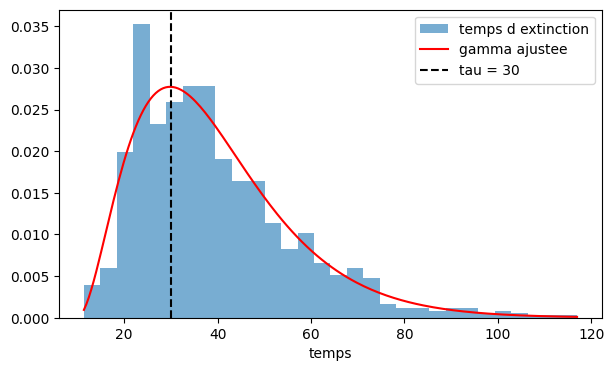

In [45]:
# on ajuste une loi gamma et on la valide par un test de Kolmogorov-Smirnov
par = scs.gamma.fit(T)
p = scs.kstest(T, scs.gamma.cdf, args=par).pvalue
print('KS loi gamma : p-value =', p)

xx = np.linspace(T.min(), T.max(), 200)
plt.figure(figsize=(7, 4))
plt.hist(T, bins=30, density=True, alpha=0.6, label='temps d extinction')
plt.plot(xx, scs.gamma.pdf(xx, *par), 'r', label='gamma ajustee')
plt.axvline(30, color='k', linestyle='--', label='tau = 30')
plt.xlabel('temps')
plt.legend()
plt.show()

## Conclusion du modèle 1

On a trouvé $\Delta t = 0.015$ et $\tau = 30$, extrait exactement le virus $X_t$, et modélisé $X_t$ par un
Ornstein-Uhlenbeck $\gamma \approx 0.07$, $m \approx -0.66$, $s \approx 0.05$, validé par simulation du
système complet. Pour l'extinction, la probabilité est négligeable pour les victimes, et le temps
d'extinction des prédateurs suit une loi gamma (KS non rejeté), avec environ $0.34$ de chance d'extinction
sur la fenêtre observée.